In [19]:
import os
import sys
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

sys.path.insert(0, current_dir)

import numpy as np
import torch
from Trainmodel     import *
from Fitting import *
from Validation     import *  
from Plotting       import *  

# Train Model with grids. 

In [11]:
MOL = 'CO2'   # 'H2O', 'C2H2', 'HCN', 'CO2'

# Input: model grid directory (one subdirectory per molecule)
GRID_DIR = f'../Model_grids/{MOL}'

# Output paths — auto-named from MOL; change the base dirs if needed
PRETRAIN_CSV = f'../Pretrain_grid/pretrain_{MOL}_11to19.csv'
MODEL_PATH   = f'../Trained_model/net_{MOL}_forward_11to19.pt'
FIG_DIR      = '../figures/validation'

In [5]:
# Per-molecule defaults — WAV_RANGE, FIT_RANGES, N_PCA differ by molecule
#
#   MOL     WAV_RANGE          FIT_RANGES                          N_PCA
#   H2O     (11.0, 19.0)       [(11.0,12.0), (17.0,18.5)]         21
#   C2H2    (12.0, 16.5)       (12.0, 16.0)                       15
#   HCN     (12.0, 16.5)       (12.0, 16.0)                       15
#   CO2     (12.0, 16.5)       (12.0, 16.0)                       15
#
_MOL_DEFAULTS = {
    'H2O':  dict(wav_range=(11.0, 19.0), fit_ranges=[(11.0,12.0),(16.5,18.5)], n_pca=21),
    'C2H2': dict(wav_range=(11.0, 17.5), fit_ranges=(12.0, 16.5),              n_pca=15),
    '13C12CH2': dict(wav_range=(11.0, 17.5), fit_ranges=(12.0, 16.5),              n_pca=15),
    'HCN':  dict(wav_range=(11.0, 17.5), fit_ranges=(12.0, 17.0),              n_pca=15),
    'CO2':  dict(wav_range=(11.0, 17.5), fit_ranges=(12.0, 17.0),              n_pca=15),
    '13CO2':  dict(wav_range=(11.0, 17.5), fit_ranges=(12.0, 17.0),              n_pca=15),
}
WAV_RANGE  = _MOL_DEFAULTS[MOL]['wav_range']
FIT_RANGES = _MOL_DEFAULTS[MOL]['fit_ranges']
N_PCA      = _MOL_DEFAULTS[MOL]['n_pca']

In [6]:
# Model architecture (same for all molecules)
HIDDEN = (64, 128, 64)   # hidden layer sizes for net_shape and net_peak

# Training hyperparameters
N_EPOCHS = 5000
BATCH    = 128
LR       = 1e-4
PATIENCE = 500   # early-stopping patience (epochs without improvement)

# Pretrain CSV options
NOISE_SCALE = 0.0   # noise as fraction of peak flux; 0.0 = noise-free
N_NOISE     = 1     # noise realisations per grid point

# Fitted parameter bounds — change these to restrict T, logN, or A search range
T_BOUNDS    = (100, 1400)    # (T_min, T_max) in K
LOGN_BOUNDS = (13.0, 19.0)   # (logN_min, logN_max) in log10(cm^-2)
LOGA_BOUNDS = (-2.0, 2.0)    # (log10A_min, log10A_max) for full validation fitting

# Holdout: grid points excluded from pretrain CSV and used as unseen validation
HOLDOUT_N      = 30     # number of grid points to hold out

In [7]:
# NT validation (T and logN only, A = 1) — gradient-based Adam optimizer
VAL_NT_FRAC    = 0.02   # fraction of pretrain CSV rows to validate (in-pretrain set)
VAL_NT_STARTS  = 100     # random starting points for Adam
VAL_NT_STEPS   = 300    # Adam gradient steps per start
VAL_NT_LR      = 0.03   # Adam learning rate

# Full validation (T, logN, A with random A)
VAL_FULL_N        = 30     # number of synthetic spectra
VAL_FULL_NOISE    = 0.001  # noise fraction for synthetic spectra
VAL_FULL_RESTARTS = 100    # fit_nested random restarts per spectrum (only used when FITTER='fit_nested')

# Full validation fitter: 'fit_nested' (random restarts) or 'fit_molecules' (Sobol global search)
FITTER = 'fit_molecules'

# fit_molecules settings (only used when FITTER='fit_molecules')
VAL_NEW_N_SAMPLES = 20000  # Sobol global screening samples
VAL_NEW_N_REFINE  = 32     # L-BFGS-B refinement candidates
VAL_NEW_N_TOP     = 10     # top solutions to retain

SEED = 42

In [8]:
#os.makedirs(FIG_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}  |  Molecule: {MOL}')

Device: cpu  |  Molecule: CO2


In [12]:
# ---------------------------------------------------------------------------
# Step 1 — Load model grid
# ---------------------------------------------------------------------------
print('\n[1] Loading model grid ...')
models   = load_model_grid(GRID_DIR)
wav_full = next(iter(models.values()))['wavelength']
print(f'    {len(models)} grid points, wav [{wav_full.min():.1f}, {wav_full.max():.1f}] µm')

# ---------------------------------------------------------------------------
# Step 1b — Select holdout grid points (excluded from pretrain CSV)
#   Computed deterministically from SEED so the same points are held out on
#   every run.  Delete the pretrain CSV to regenerate it with a new holdout.
# ---------------------------------------------------------------------------
print(f'\n[1b] Selecting {HOLDOUT_N} holdout grid points ...')
_all_keys    = list(models.keys())
_rng_holdout = np.random.default_rng(SEED)
_holdout_idx = _rng_holdout.choice(len(_all_keys), size=min(HOLDOUT_N, len(_all_keys)),
                                   replace=False)
holdout_keys     = [_all_keys[i] for i in sorted(_holdout_idx)]
holdout_keys_set = set(map(tuple, holdout_keys))
print(f'    {len(holdout_keys)} holdout keys (T range {min(k[0] for k in holdout_keys)}'
      f'–{max(k[0] for k in holdout_keys)} K, '
      f'logN range {min(k[1] for k in holdout_keys):.2f}'
      f'–{max(k[1] for k in holdout_keys):.2f})')


[1] Loading model grid ...
    2597 grid points, wav [11.0, 19.0] µm

[1b] Selecting 30 holdout grid points ...
    30 holdout keys (T range 150–1225 K, logN range 13.00–18.75)


In [13]:
# ---------------------------------------------------------------------------
# Step 2 — Generate pretrain CSV (skipped if the file already exists)
#   NOTE: if the CSV was generated in a previous run without holdout_keys,
#   delete it so it is regenerated with the correct holdout exclusions.
# ---------------------------------------------------------------------------
print('\n[2] Pretrain CSV ...')
if not os.path.exists(PRETRAIN_CSV):
    generate_pre_training_set(
        MOL, models,
        output_path=PRETRAIN_CSV,
        wav_out=wav_full,
        noise_scale=NOISE_SCALE,
        n_noise=N_NOISE,
        seed=SEED,
        holdout_keys=holdout_keys_set,
    )
else:
    print(f'    Exists, skipping → {PRETRAIN_CSV}')



[2] Pretrain CSV ...
  [CO2] 30 grid points excluded as holdout (2567 kept for pretraining)
[pretrain CSV] 2567 rows (2567 grid pts × 1 noise) → ../Pretrain_grid/pretrain_CO2_11to19.csv


In [14]:
# ---------------------------------------------------------------------------
# Step 3 — Train (or load) the forward model
#           pretrain_forward_model loads from MODEL_PATH if it already exists
# ---------------------------------------------------------------------------
print('\n[3] Training forward model ...')
pretrain_forward_model(
    mol=MOL,
    pretrain_csv=PRETRAIN_CSV,
    wav_range=WAV_RANGE,
    device=device,
    hidden=HIDDEN,
    n_pca=N_PCA,
    n_epochs=N_EPOCHS,
    batch_size=BATCH,
    lr=LR,
    early_stopping_patience=PATIENCE,
    model_path=MODEL_PATH,
    seed=SEED,
)


[3] Training forward model ...
  [CO2] wav_range=(11.0, 17.5)  n_spec=2859 → PCA n=15  cumul. var=99.9881%
  [CO2] loaded from ../Trained_model/net_CO2_forward_11to19.pt


{'net_shape': MLP(
   (net): Sequential(
     (0): Linear(in_features=2, out_features=64, bias=True)
     (1): ReLU()
     (2): Linear(in_features=64, out_features=128, bias=True)
     (3): ReLU()
     (4): Linear(in_features=128, out_features=64, bias=True)
     (5): ReLU()
     (6): Linear(in_features=64, out_features=15, bias=True)
   )
 ),
 'net_peak': MLP(
   (net): Sequential(
     (0): Linear(in_features=2, out_features=64, bias=True)
     (1): ReLU()
     (2): Linear(in_features=64, out_features=128, bias=True)
     (3): ReLU()
     (4): Linear(in_features=128, out_features=64, bias=True)
     (5): ReLU()
     (6): Linear(in_features=64, out_features=1, bias=True)
   )
 ),
 'xp_sc': StandardScaler(),
 'yp_sc_shape': StandardScaler(),
 'yp_sc_peak': StandardScaler(),
 'pca': PCA(n_components=15, random_state=42),
 'train_losses_shape': [0.9768562630603188,
  0.9771912568493893,
  0.9695000585756803,
  0.9912728416292291,
  0.9419975092536524,
  0.9940374587711535,
  0.8994718225

In [15]:
# ---------------------------------------------------------------------------
# Step 4 — Load model via the standard Fitting API
# ---------------------------------------------------------------------------
print('\n[4] Loading model for fitting ...')
pretrained = load_models(
    model_paths        = {MOL: MODEL_PATH},
    pretrain_csv_paths = {MOL: PRETRAIN_CSV},
    wav_ranges         = {MOL: WAV_RANGE},
    n_pca              = {MOL: N_PCA},
    device=device,
)


[4] Loading model for fitting ...
  [CO2] wav_range=(11.0, 17.5)  n_spec=2859 → PCA n=15  cumul. var=99.9881%
  [CO2] loaded from ../Trained_model/net_CO2_forward_11to19.pt
  Loaded CO2 from ../Trained_model/net_CO2_forward_11to19.pt


In [ ]:
# ---------------------------------------------------------------------------
# Step 5 — NT validation: in-pretrain set + holdout set, plotted separately
# ---------------------------------------------------------------------------
print('\n[5a] NT validation — in-pretrain grid points ...')
nt_pretrain = validate_nt(
    MOL, pretrained, PRETRAIN_CSV, FIT_RANGES,
    frac=VAL_NT_FRAC,
    T_bounds=T_BOUNDS,
    logN_bounds=LOGN_BOUNDS,
    n_starts=VAL_NT_STARTS,
    n_steps=VAL_NT_STEPS,
    lr=VAL_NT_LR,
    seed=SEED,
)

print('\n[5b] NT validation — holdout (unseen) grid points ...')
nt_holdout = validate_nt_holdout(
    MOL, pretrained, models, holdout_keys, FIT_RANGES,
    T_bounds=T_BOUNDS,
    logN_bounds=LOGN_BOUNDS,
    n_starts=VAL_NT_STARTS,
    n_steps=VAL_NT_STEPS,
    lr=VAL_NT_LR,
)



[5a] NT validation — in-pretrain grid points ...
[CO2] NT validation: 51 spectra ...
  10/51
  20/51
  30/51


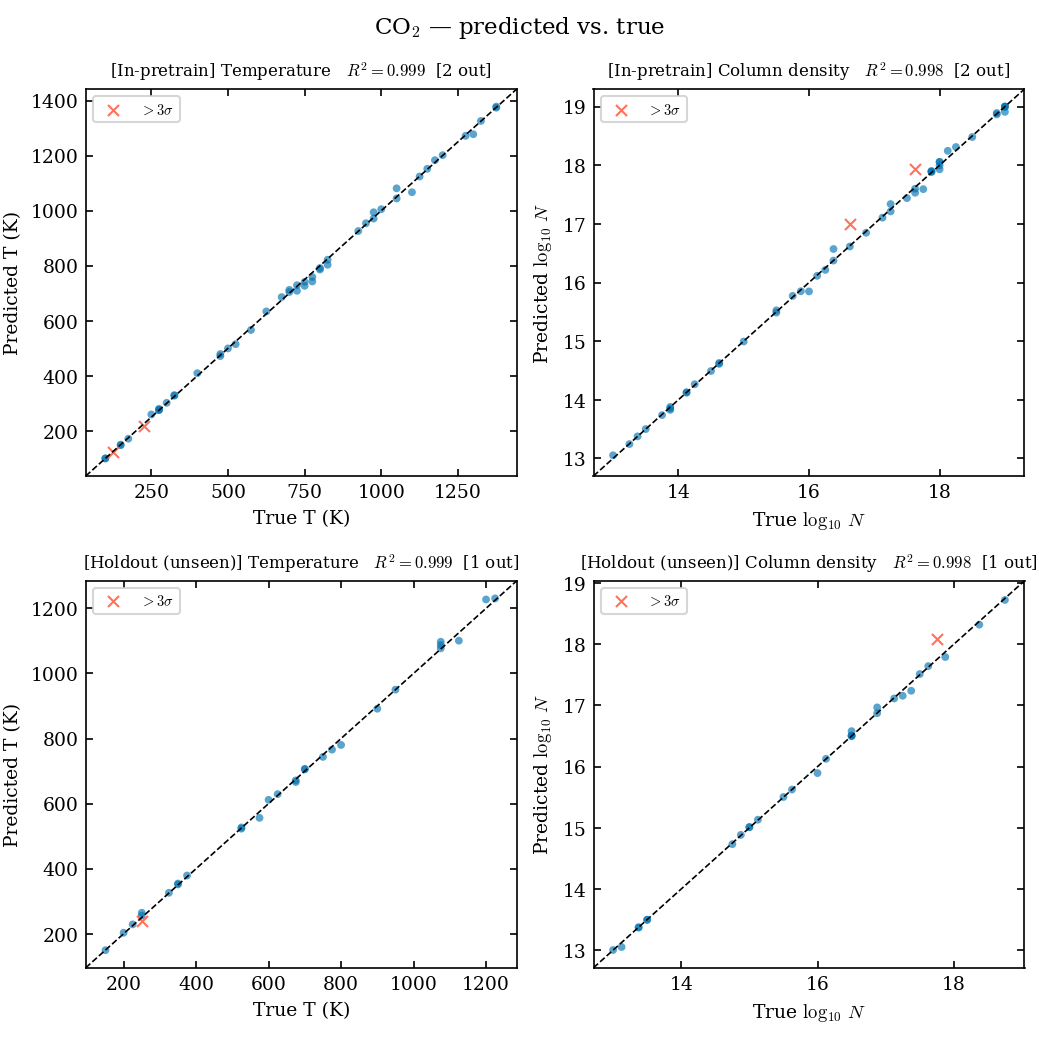

In [21]:
plot_validation_split(MOL, nt_pretrain, nt_holdout,
                      save_path=None)